In [ ]:
import os
if os.getcwd().endswith("analysis"): os.chdir("..")
print(os.getcwd())

import ipynbname
__file__ = ipynbname.path()

/mnt/mergerfs/yuzihan/MergedWorkSpace/42-MySRAgent/SRAgent


In [ ]:
from __future__ import annotations
import re
import os
import sys
import time
import json
import h5py
import shlex
import dotenv
import logging
import argparse
import datasets
import numpy as np
import nd2py as nd
from pathlib import Path
from datetime import datetime
from socket import gethostname
from typing import Any, Callable, Dict, List, Optional
from scipy.stats import kendalltau
from sklearn.metrics import mean_absolute_percentage_error
from sr_agent.utils import setup_logging, log_exception, tag2ansi, seed_all, add_minus_flags, add_negation_flags, get_symbolic_acc, sanitize_filename, save_args
from bench_sr_agent import build_argparser
from sr_agent._vendor.llmsr_bench.core import SEDTask, SRResult, Problem
from sr_agent._vendor.llmsr_bench.algorithms import get_update_parser, get_algorithm, list_algorithms

DATASET_SPLITS = {
    "lsrtransform": "lsr_transform",
    "bio_pop_growth": "lsr_synth_bio_pop_growth",
    "chem_react": "lsr_synth_chem_react",
    "matsci": "lsr_synth_matsci",
    "phys_osc": "lsr_synth_phys_osc",
}

dotenv.load_dotenv()  # Load environment variables from .env file if present
SCRIPT_NAME = Path(__file__).stem
_logger = logging.getLogger(f"sr_agent.{SCRIPT_NAME}")

/data2/yuzihan/MergedWorkSpace/42-MySRAgent/SRAgent/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [8]:
parser = build_argparser()
args, unknown = parser.parse_known_args()

args.exp_name = sanitize_filename(SCRIPT_NAME)
args.verbose = True
args.seed = 42
# seed_all(args.seed)
save_path = Path(args.save_dir) / args.exp_name
save_path.mkdir(parents=True, exist_ok=True)
args.save_path = str(save_path)
args.command = " ".join(map(shlex.quote, [sys.executable, *sys.argv]))

# setup_logging(
#     info_level="debug" if args.verbose else "info",
#     exp_name=args.exp_name,
#     save_path=save_path / "info.log",
#     force=True,
# )

if unknown:
    _logger.warning(f"Unknown args: {unknown}")
_logger.note(f"Args: {args}")

save_args(args, save_path / "args.json")

# main(args)
# _logger.note(tag2ansi(f"Experiment completed. Re-run the script with [green bold]{args.command}[reset]"))

Unknown args: ['--f=/run/user/1015/jupyter/runtime/kernel-v33b6ccc4dc60519a0583fb8b90e0ed498665f0b0f.json']


In [9]:
def load_problems(dataset_name: str, data_root: str, hf_repo_id = "nnheui/llm-srbench") -> List[Problem]:
    """
    从 HuggingFace + HDF5 加载指定数据集的所有问题

    HDF5 键名:
    - LSR-Transform: 'train', 'test'
    - LSR-Synth: 'train', 'test', 'ood_test'

    注意: 原始 benchmark 代码 (datamodules.py) 中 SynProblem 类使用了
    不同的属性名映射 (train_data, id_test_data, ood_test_data),
    但 HDF5 文件中的实际键名已统一为 train, test, ood_test。
    """
    split_name = DATASET_SPLITS[dataset_name]

    # 尝试从本地 parquet 文件加载公式元信息
    data_dir = Path(data_root) / "data"
    if not data_dir.exists():
        _logger.note(f"Local parquet not found. Downloading from {hf_repo_id}... (If you wait too long, consider downloading it manually)")
        ds = datasets.load_dataset(hf_repo_id, split=split_name, cache_dir='./data/hf_cache')
    elif not (data_path := data_dir.glob(f"{split_name}-*.parquet").__iter__().__next__()).exists():
        _logger.note(f"Local parquet not found. Downloading from {hf_repo_id}... (If you wait too long, consider downloading it manually)")
        ds = datasets.load_dataset(hf_repo_id, split=split_name, cache_dir='./data/hf_cache')
    else:
        _logger.note(f"Loading parquet from local: {data_path}")
        ds = datasets.load_dataset("parquet", data_files=str(data_path), split="train")

    # 从 HDF5 读取数值样本
    h5file_path = Path(data_root) / "lsr_bench_data.hdf5"
    problems = []
    with h5py.File(h5file_path, "r") as f:
        for entry in ds:
            name = entry["name"]
            # HDF5 路径: /lsr_transform/<name> 或 /lsr_synth/<domain>/<name>
            if split_name == "lsr_transform":
                h5_path = f"/lsr_transform/{name}"
            else:
                h5_path = f"/lsr_synth/{dataset_name}/{name}"
            
            expression = entry["expression"]
            samples = {k: v[...].astype(np.float64) for k, v in f[h5_path].items()}

            # expression 中有一些 P(t) 这样的写法，需要将它替换成 P
            for symbol in entry['symbols']:
                try: 
                    expression = re.sub(rf"\b{re.escape(symbol)}\b\(t\)", symbol, expression)
                except Exception as e:
                    _logger.warning(f"Failed to replace {symbol}(t) -> {symbol} in {entry['expression']!r}")
            
            # expression 中有一些 pi, e 这样的常数, 确保除此之外没有别的常数
            try:
                formula = nd.parse(expression)
                for var in formula.iter_preorder():
                    if not isinstance(var, nd.Variable): pass
                    elif var.name in entry['symbols']: pass
                    elif var.name.lower() in ['pi', 'e']: pass
                    else: raise ValueError(f"Unknown variable {var.name!r}.")
            except Exception as e:
                _logger.warning(f"Error parsing expression {expression!r} for {name} in {dataset_name}: {log_exception(e)}.")
                continue

            problems.append(Problem(
                dataset_identifier=dataset_name,
                equation_idx=name,
                symbols=entry["symbols"],
                symbol_descs=entry["symbol_descs"],
                symbol_properties=entry["symbol_properties"],
                expression=expression,
                samples=samples,
            ))
    return problems


In [ ]:
import numpy as np
import nd2py as nd
import pandas as pd

df_list = []
for problem in load_problems('lsrtransform', './data/llm-srbench-data'):
    data = pd.DataFrame(problem.train_samples, columns=problem.symbols)
    y_pred = nd.parse(problem.expression).eval({'pi': np.pi, 'e': np.e, **data})
    y_true = problem.train_samples[:, 0]
    metric = dict(
        mae = np.mean(np.abs(y_pred - y_true)),
        rmse = np.sqrt(np.mean((y_pred - y_true) ** 2)),
        r2 = 1 - np.sum((y_true - y_pred) ** 2) / np.sum((y_true - np.mean(y_true)) ** 2),
        mape = mean_absolute_percentage_error(y_true, y_pred),
    )
    df_list.append({
        'problem': problem.equation_idx,
        'expression': problem.expression,
        **metric
    })

df_metric = pd.DataFrame(df_list).sort_values('r2')
df_metric

,problem,expression,mae,rmse,r2,mape
32,II.24.17_2_1,pi*c*sqrt(-1/((c*k - omega)*(c*k + omega))),8.850998e-02,1.656371e+01,0.618418,1.806768e-05
106,I.50.26_0_0,x/(alpha*cos(omega*t)**2 + cos(omega*t)),1.006366e+01,2.830590e+03,0.991127,2.831641e-06
100,I.50.26_3_0,(x/cos(omega*t) - x1)/(x1*cos(omega*t)),2.242942e+03,4.820932e+05,0.999647,2.085533e-06
0,II.6.15b_1_0,8*pi*Ef*epsilon*r**3/(3*sin(2*theta)),6.504485e-01,1.717739e+02,0.999826,5.407409e-07
79,I.44.4_2_0,E_n/(kb*n*log(V2/V1)),1.160959e+00,3.229280e+02,0.999837,6.825837e-07
...,...,...,...,...,...,...
47,I.12.2_3_0,-sqrt(q1*q2/(F*epsilon))/(2*sqrt(pi)),2.996388e-08,5.371589e-08,1.000000,2.921184e-08
25,I.12.4_2_0,-sqrt(q1/(Ef*epsilon))/(2*sqrt(pi)),2.954049e-08,4.804611e-08,1.000000,2.739114e-08
40,II.11.27_0_0,3*Pol/(alpha*(3*Ef*epsilon + Pol)),3.154621e-07,8.624278e-06,1.000000,3.815560e-08
78,II.11.27_1_0,3*Pol/(n*(3*Ef*epsilon + Pol)),3.154621e-07,8.624278e-06,1.000000,3.815560e-08


{'mae': np.float64(0.08850997993199004), 'rmse': np.float64(16.56370832466251), 'r2': np.float64(0.6184183759122672), 'mape': 1.80676798760084e-05}


[]

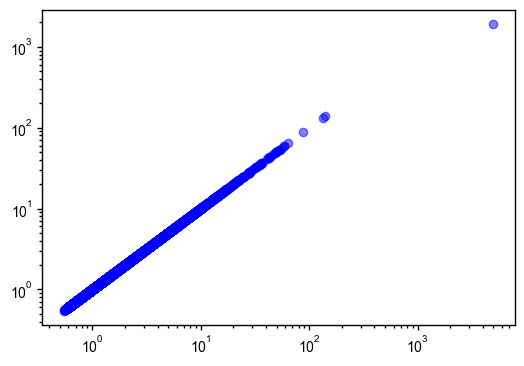

In [38]:
problems = load_problems('lsrtransform', './data/llm-srbench-data')
problem = [p for p in problems if p.equation_idx == 'II.24.17_2_1'][0]
data = pd.DataFrame(problem.train_samples, columns=problem.symbols)
y_pred = nd.parse(problem.expression).eval({'pi': np.pi, 'e': np.e, **data})
y_true = problem.train_samples[:, 0]
metric = dict(
    mae = np.mean(np.abs(y_pred - y_true)),
    rmse = np.sqrt(np.mean((y_pred - y_true) ** 2)),
    r2 = 1 - np.sum((y_true - y_pred) ** 2) / np.sum((y_true - np.mean(y_true)) ** 2),
    mape = mean_absolute_percentage_error(y_true, y_pred),
)
print(metric)

from sr_agent.utils.plot import get_fig
fi, fig, axes = get_fig(1, 1, AW=12, AH=8, fontsize=14, dpi=100, lw=1)
ax = axes[0]
ax.scatter(y_true, y_pred, color='blue', alpha=0.5)
ax.loglog()

In [39]:
import numpy as np
import nd2py as nd
import pandas as pd

df_list = []
for problem in load_problems('bio_pop_growth', './data/llm-srbench-data'):
    data = pd.DataFrame(problem.train_samples, columns=problem.symbols)
    y_pred = nd.parse(problem.expression).eval({'pi': np.pi, 'e': np.e, **data})
    y_true = problem.train_samples[:, 0]
    metric = dict(
        mae = np.mean(np.abs(y_pred - y_true)),
        rmse = np.sqrt(np.mean((y_pred - y_true) ** 2)),
        r2 = 1 - np.sum((y_true - y_pred) ** 2) / np.sum((y_true - np.mean(y_true)) ** 2),
        mape = mean_absolute_percentage_error(y_true, y_pred),
    )
    df_list.append({
        'problem': problem.equation_idx,
        'expression': problem.expression,
        **metric
    })

df_metric = pd.DataFrame(df_list).sort_values('r2')
df_metric

,problem,expression,mae,rmse,r2,mape
16,BPG16,0.8677806610632854*(-1 + P/6.057935627201261)*...,2.052335e-06,2.428006e-06,1.0,3.601367e-04
18,BPG18,0.4770530111687279*P*sin(0.7760602430275763*t)...,1.460937e-05,2.221334e-05,1.0,2.035957e-06
9,BPG9,0.1699888096710614*(-1 + P/1.0472843670254641)...,4.064922e-07,4.968410e-07,1.0,3.337742e-04
12,BPG12,0.8770002846146427*P*sin(0.5671736066225963*t)...,1.197625e-05,2.065966e-05,1.0,2.983368e-06
13,BPG13,0.20107390997009728*(-1 + P/5.636576533003584)...,5.840639e-07,7.284975e-07,1.0,3.836741e-04
2,BPG2,0.2569297861044923*P*sin(0.7218439642922193*t)...,1.059763e-06,1.901657e-06,1.0,7.980411e-06
20,BPG20,0.13870625668024555*(-1 + P/8.038138014396704)...,2.075863e-06,2.875268e-06,1.0,2.831985e-04
8,BPG8,0.9909642091509507*(1 - P/39.01184604772507)*P...,3.785414e-06,4.439456e-06,1.0,2.686421e-04
23,BPG23,0.5980421690791728*(1 - P/32.93940240233941)*P...,1.926196e-06,2.362802e-06,1.0,3.909741e-04
7,BPG7,0.7213553457664288*(-1 + P/6.6511035054181695)...,4.211098e-07,5.000257e-07,1.0,2.861141e-04


In [40]:
import numpy as np
import nd2py as nd
import pandas as pd

df_list = []
for problem in load_problems('matsci', './data/llm-srbench-data'):
    data = pd.DataFrame(problem.train_samples, columns=problem.symbols)
    y_pred = nd.parse(problem.expression).eval({'pi': np.pi, 'e': np.e, **data})
    y_true = problem.train_samples[:, 0]
    metric = dict(
        mae = np.mean(np.abs(y_pred - y_true)),
        rmse = np.sqrt(np.mean((y_pred - y_true) ** 2)),
        r2 = 1 - np.sum((y_true - y_pred) ** 2) / np.sum((y_true - np.mean(y_true)) ** 2),
        mape = mean_absolute_percentage_error(y_true, y_pred),
    )
    df_list.append({
        'problem': problem.equation_idx,
        'expression': problem.expression,
        **metric
    })

df_metric = pd.DataFrame(df_list).sort_values('r2')
df_metric

,problem,expression,mae,rmse,r2,mape
20,MatSci22,72.33109007775502*epsilon**2 + epsilon*7.74654...,0.000012,0.000021,1.0,8.045245e-06
1,MatSci1,7.773814951275034*epsilon**3 + 55.124317654984...,0.000006,0.000010,1.0,1.490181e-07
23,MatSci25,83.23132137098519*epsilon**0.9685242195998613*...,0.000007,0.000011,1.0,2.693938e-07
6,MatSci6,21.698090453033654*epsilon*(-0.054603349408929...,0.003575,0.007155,1.0,4.778424e-07
16,MatSci18,2.353524517872731*epsilon**2 + epsilon*6.26634...,0.004039,0.008007,1.0,7.239644e-07
10,MatSci10,7.722936175676248*epsilon**3 + 36.658873499715...,0.000955,0.001892,1.0,2.529167e-07
19,MatSci21,28.580443564163904*epsilon**2 - 0.285700346565...,0.000003,0.000005,1.0,7.474708e-07
2,MatSci2,7.317170963605775*epsilon**3 + 7.9502029236699...,0.000053,0.000064,1.0,5.831005e-07
9,MatSci9,4.255830478818137*epsilon**3 - 0.3902956878147...,0.000006,0.000010,1.0,9.013153e-07
5,MatSci5,61.34686906400979*epsilon*(-0.0507652232996572...,0.000004,0.000006,1.0,1.343537e-06


In [41]:
import numpy as np
import nd2py as nd
import pandas as pd

df_list = []
for problem in load_problems('phys_osc', './data/llm-srbench-data'):
    data = pd.DataFrame(problem.train_samples, columns=problem.symbols)
    y_pred = nd.parse(problem.expression).eval({'pi': np.pi, 'e': np.e, **data})
    y_true = problem.train_samples[:, 0]
    metric = dict(
        mae = np.mean(np.abs(y_pred - y_true)),
        rmse = np.sqrt(np.mean((y_pred - y_true) ** 2)),
        r2 = 1 - np.sum((y_true - y_pred) ** 2) / np.sum((y_true - np.mean(y_true)) ** 2),
        mape = mean_absolute_percentage_error(y_true, y_pred),
    )
    df_list.append({
        'problem': problem.equation_idx,
        'expression': problem.expression,
        **metric
    })

df_metric = pd.DataFrame(df_list).sort_values('r2')
df_metric

Error parsing expression 'F0*sin(t) - beta*sin(v) - omega0**2*x**3 - omega0**2*x*exp(-Abs(x))' for PO0 in phys_osc: ValueError: Unknown variable 'F0'.
Traceback (most recent call last):
  File "/tmp/ipykernel_914244/3766627635.py", line 56, in load_problems
    else: raise ValueError(f"Unknown variable {var.name!r}.")
          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
ValueError: Unknown variable 'F0'.
.
Error parsing expression 'F0*sin(t) - omega0**2*x - omega0**2*x*exp(-Abs(x))' for PO1 in phys_osc: ValueError: Unknown variable 'F0'.
Traceback (most recent call last):
  File "/tmp/ipykernel_914244/3766627635.py", line 56, in load_problems
    else: raise ValueError(f"Unknown variable {var.name!r}.")
          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
ValueError: Unknown variable 'F0'.
.
Error parsing expression '-alpha*v**3 - mu*(1 - x**2)*v - omega0**2*x - omega0**2*x*exp(-Abs(x))' for PO2 in phys_osc: ValueError: Unknown variable 'alpha'.
Traceback (most recent

KeyError: 'r2'

In [ ]:
dataset_name = 'phys_osc'
data_root = './data/llm-srbench-data'
hf_repo_id = "nnheui/llm-srbench"
split_name = DATASET_SPLITS[dataset_name]

# 尝试从本地 parquet 文件加载公式元信息
data_dir = Path(data_root) / "data"
if not data_dir.exists():
    _logger.note(f"Local parquet not found. Downloading from {hf_repo_id}... (If you wait too long, consider downloading it manually)")
    ds = datasets.load_dataset(hf_repo_id, split=split_name, cache_dir='./data/hf_cache')
elif not (data_path := data_dir.glob(f"{split_name}-*.parquet").__iter__().__next__()).exists():
    _logger.note(f"Local parquet not found. Downloading from {hf_repo_id}... (If you wait too long, consider downloading it manually)")
    ds = datasets.load_dataset(hf_repo_id, split=split_name, cache_dir='./data/hf_cache')
else:
    _logger.note(f"Loading parquet from local: {data_path}")
    ds = datasets.load_dataset("parquet", data_files=str(data_path), split="train")

# 从 HDF5 读取数值样本
h5file_path = Path(data_root) / "lsr_bench_data.hdf5"
problems = []
with h5py.File(h5file_path, "r") as f:
    for entry in ds:
        name = entry["name"]
        # HDF5 路径: /lsr_transform/<name> 或 /lsr_synth/<domain>/<name>
        if split_name == "lsr_transform":
            h5_path = f"/lsr_transform/{name}"
        else:
            h5_path = f"/lsr_synth/{dataset_name}/{name}"
        
        expression = entry["expression"]
        samples = {k: v[...].astype(np.float64) for k, v in f[h5_path].items()}

        # expression 中有一些 P(t) 这样的写法，需要将它替换成 P
        for symbol in entry['symbols']:
            try: 
                expression = re.sub(rf"\b{re.escape(symbol)}\b\(t\)", symbol, expression)
            except Exception as e:
                _logger.warning(f"Failed to replace {symbol}(t) -> {symbol} in {entry['expression']!r}")
        
        # expression 中有一些 pi, e 这样的常数, 确保除此之外没有别的常数
        formula = nd.parse(expression)
        for var in formula.iter_preorder():
            if not isinstance(var, nd.Variable): pass
            elif var.name in entry['symbols']: pass
            elif var.name.lower() in ['pi', 'e']: pass
            else: raise ValueError(f"Unknown variable {var.name!r}.")

        problems.append(Problem(
            dataset_identifier=dataset_name,
            equation_idx=name,
            symbols=entry["symbols"],
            symbol_descs=entry["symbol_descs"],
            symbol_properties=entry["symbol_properties"],
            expression=expression,
            samples=samples,
        ))


ValueError: Unknown variable 'F0'.

In [ ]:
nd.parse(expression)

'F0*sin(t) - beta*sin(v) - omega0**2*x**3 - omega0**2*x*exp(-Abs(x))'

In [47]:
pd.DataFrame(samples['train'], columns=entry["symbols"])

,dv_dt,x,t,v
0,-0.195509,0.563797,20.276054,1.056813
1,1.278330,-1.044757,6.321264,0.443936
2,0.888011,-0.881416,6.593318,0.737916
3,0.054812,0.045852,13.450690,1.095637
4,0.172116,-0.537438,35.951191,-1.066202
...,...,...,...,...
3995,-1.520504,1.170439,14.626925,0.494444
3996,-0.207348,0.528601,16.051210,-0.959365
3997,1.657011,-1.222718,18.027605,-0.147865
3998,0.508020,0.523175,1.632326,-0.038180
